###1. Load dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

input_path = "/content/drive/MyDrive/student-risk-ml-project/data/processed/student_ml_ready.csv"

df = pd.read_csv(input_path)

print("Shape:", df.shape)
df.head()

Shape: (649, 44)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other,At_Risk
0,0,0,18,1,1,0,4,4,2,2,...,0,1,1,0,0,0,0,1,0,0
1,0,0,17,1,1,1,1,1,1,2,...,0,0,1,0,0,0,1,0,0,0
2,0,0,15,1,0,1,1,1,1,2,...,0,0,0,0,1,0,0,1,0,0
3,0,0,15,1,1,1,4,2,1,3,...,1,0,0,1,0,0,0,1,0,0
4,0,0,16,1,1,1,3,3,1,2,...,0,0,0,1,0,0,1,0,0,0


###2. Separate features and target

In [3]:
X = df.drop(columns=["At_Risk"])
y = df["At_Risk"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (649, 43)
y shape: (649,)


###3. Same train/test split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (519, 43)
X_test : (130, 43)


###4. Train the Decision Tree

In [5]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

###5. Make predictions

In [6]:
y_pred = dt_model.predict(X_test)

In [7]:
y_prob = dt_model.predict_proba(X_test)[:, 1]

###6. Evaluate

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.8461538461538461
Precision: 0.5
Recall   : 0.35
F1 Score : 0.4117647058823529
ROC-AUC  : 0.7777272727272726


In [9]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       110
           1       0.50      0.35      0.41        20

    accuracy                           0.85       130
   macro avg       0.69      0.64      0.66       130
weighted avg       0.83      0.85      0.83       130



###7. Confusion matrix

In [10]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[103   7]
 [ 13   7]]


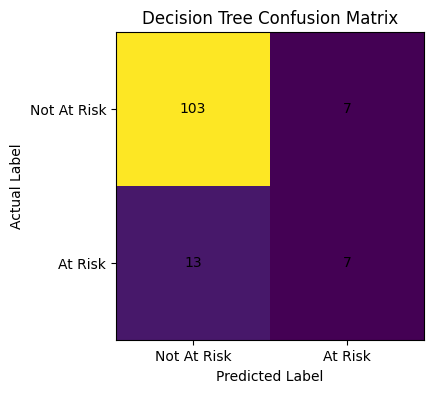

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.imshow(cm)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1], ["Not At Risk", "At Risk"])
plt.yticks([0, 1], ["Not At Risk", "At Risk"])

plt.show()

###8. Check training accuracy too

In [12]:
train_accuracy = dt_model.score(X_train, y_train)
test_accuracy = dt_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 0.9075144508670521
Testing Accuracy : 0.8461538461538461


###9. Feature importance

In [13]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
10,failures,0.341126
37,reason_home,0.116543
25,absences,0.074463
16,higher,0.061981
24,health,0.048498
23,Walc,0.039537
0,school,0.038821
4,famsize,0.036157
14,activities,0.035569
7,Fedu,0.034980


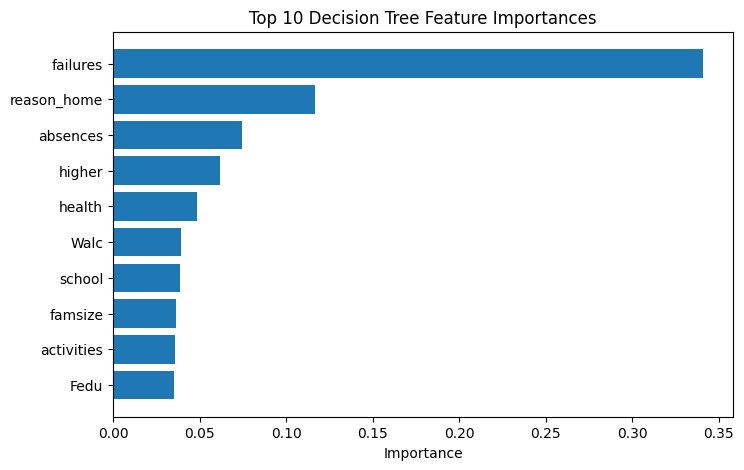

In [14]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 10 Decision Tree Feature Importances")
plt.xlabel("Importance")

plt.show()

###10.visualize the actual tree

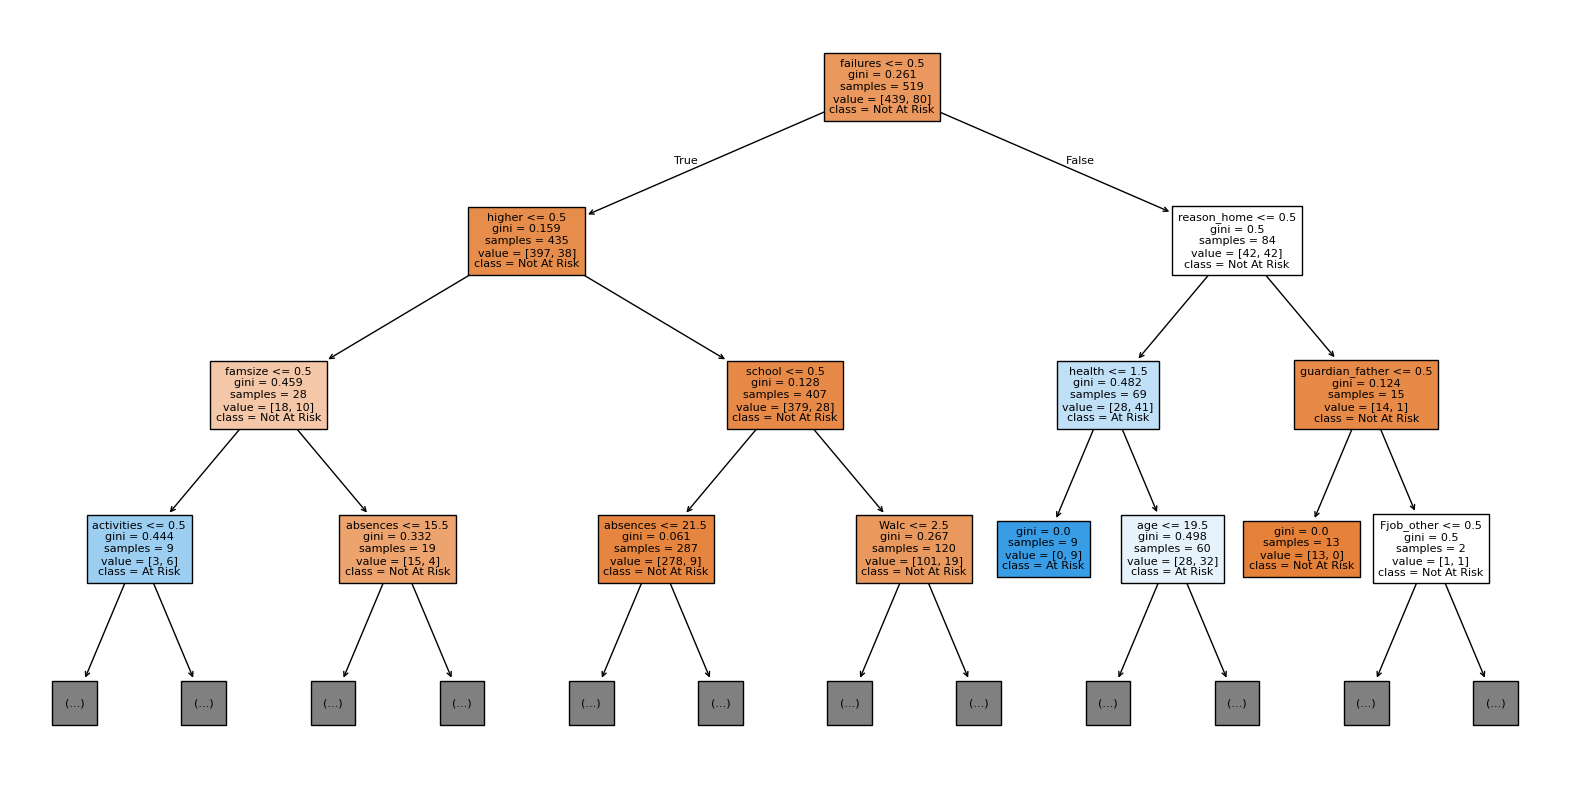

In [15]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Not At Risk", "At Risk"],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.show()

###11. Save results

In [16]:
decision_tree_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc]
})

decision_tree_results

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Decision Tree,0.846154,0.5,0.35,0.411765,0.777727


In [17]:
output_path = "/content/drive/MyDrive/student-risk-ml-project/data/processed/decision_tree_results.csv"

decision_tree_results.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: /content/drive/MyDrive/student-risk-ml-project/data/processed/decision_tree_results.csv


## ***Decision Tree Summary***

A Decision Tree Classifier was trained as the second model for identifying At-Risk students.

The same 80/20 stratified train-test split and `random_state=42` were used to ensure a fair comparison with Logistic Regression.

Feature scaling was not applied because Decision Trees make predictions using feature-based threshold splits and are not sensitive to feature scale.

The tree depth was limited to reduce the risk of overfitting.

The model was evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC

Training and testing accuracy were also compared to investigate possible overfitting.

Feature importance was examined to identify variables that contributed most strongly to the model's predictions.